## Help your hedge fund manager!

You have two datasets at your disposal: `Balance_Sheet.xlsx` and `Income_Statement.xlsx`. Both these datasets have three columns in common:
- `"Company"`: The company's ticker name.
- `"comp_type"` The type of industry the company in question belongs to. It is either `"tech"` for companies in the technology industry, `"fmcg"` for companies in the fast-moving consumer goods industry, and `"real_est"` for companies in the real estate industry. 
- `"Year"`: The year the company's information is from.

The rest of the columns in the datasets contain information from the financial statement of the `"Company"` in question. Note that the columns in `Balance_Sheet.xlsx` only contain financial information from the balance sheet. Similarly, the columns in `Income_Statement.xlsx` only contain financial information from the income statement. The columns are named accordingly. For instance, the column `"Total Liab"` from `Balance_Sheet.xlsx` is the total liability.

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
balance_sheet = pd.read_excel("data/Balance_Sheet.xlsx")
income_statement = pd.read_excel("data/Income_Statement.xlsx")

# Quick data inspection
print(balance_sheet.info())
print(balance_sheet.head())

print(income_statement.info())
print(income_statement.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 60 non-null     int64  
 1   Year                       60 non-null     int64  
 2   comp_type                  60 non-null     object 
 3   company                    60 non-null     object 
 4   Accounts Payable           60 non-null     int64  
 5   Cash                       60 non-null     int64  
 6   Inventory                  44 non-null     float64
 7   Property Plant Equipment   60 non-null     int64  
 8   Short Term Investments     37 non-null     float64
 9   Total Assets               60 non-null     int64  
 10  Total Current Assets       60 non-null     int64  
 11  Total Current Liabilities  60 non-null     int64  
 12  Total Liab                 60 non-null     int64  
 13  Total Stockholder Equity   60 non-null     int64  
d

To successfully complete the project for your manager, please compute two ratios:

A debt-to-equity ratio or an equity multiplier ratio. Save this ratio in a column named "leverage_ratio" in a DataFrame called df_ratios.

A gross margin ratio or an operating margin ratio. Save this ratio in a column named "profitability_ratio", in a DataFrame called df_ratios.

In [18]:
# Merge balance sheet and income statement data
df_ratios = pd.merge(balance_sheet, income_statement, on=["Year", "company", "comp_type"])

# Calculate leverage ratio
df_ratios["leverage_ratio"] = df_ratios["Total Liab"] / df_ratios["Total Stockholder Equity"]

# Calculate profitability ratio
df_ratios["profitability_ratio"] = (df_ratios["Total Revenue"] - df_ratios["Cost Of Goods Sold"]) / df_ratios["Total Revenue"]

The datasets provided to you have information on the type of industry a company belongs to in a column called comp_type. Your manager also needs you to answer these three questions:

Which company type (comp_type) has the lowest profitability ratio? Save this comp_type value as a string in a variable called lowest_profitability.

In [19]:
# Group by comp_type and calculate average profitability ratio
print(df_ratios.groupby("comp_type")["profitability_ratio"].mean())

# Alternative: Use pivot table to get the same result
print(df_ratios.pivot_table(index="comp_type", values="profitability_ratio"))

# Identify the comp_type with the lowest profitability
lowest_profitability = "fmcg"


comp_type
fmcg        0.514396
real_est    0.534848
tech        0.572062
Name: profitability_ratio, dtype: float64
           profitability_ratio
comp_type                     
fmcg                  0.514396
real_est              0.534848
tech                  0.572062


Which company type has the highest leverage ratio? Save this comp_type value as a string in a variable called highest_leverage.

In [20]:
# Group by comp_type and calculate average leverage ratio
print(df_ratios.groupby("comp_type")["leverage_ratio"].mean())

# Alternative: Use pivot table to get the same result
print(df_ratios.pivot_table(index="comp_type", values="leverage_ratio"))

# Identify the comp_type with the highest leverage
highest_leverage = "real_est"

comp_type
fmcg        2.997896
real_est    5.692041
tech        1.777448
Name: leverage_ratio, dtype: float64
           leverage_ratio
comp_type                
fmcg             2.997896
real_est         5.692041
tech             1.777448


What is the relationship between leverage and profitability in the real estate companies represented in this data? Is it "positive," "negative," or "no relationship?" Save one of these three strings in a variable called relationship.

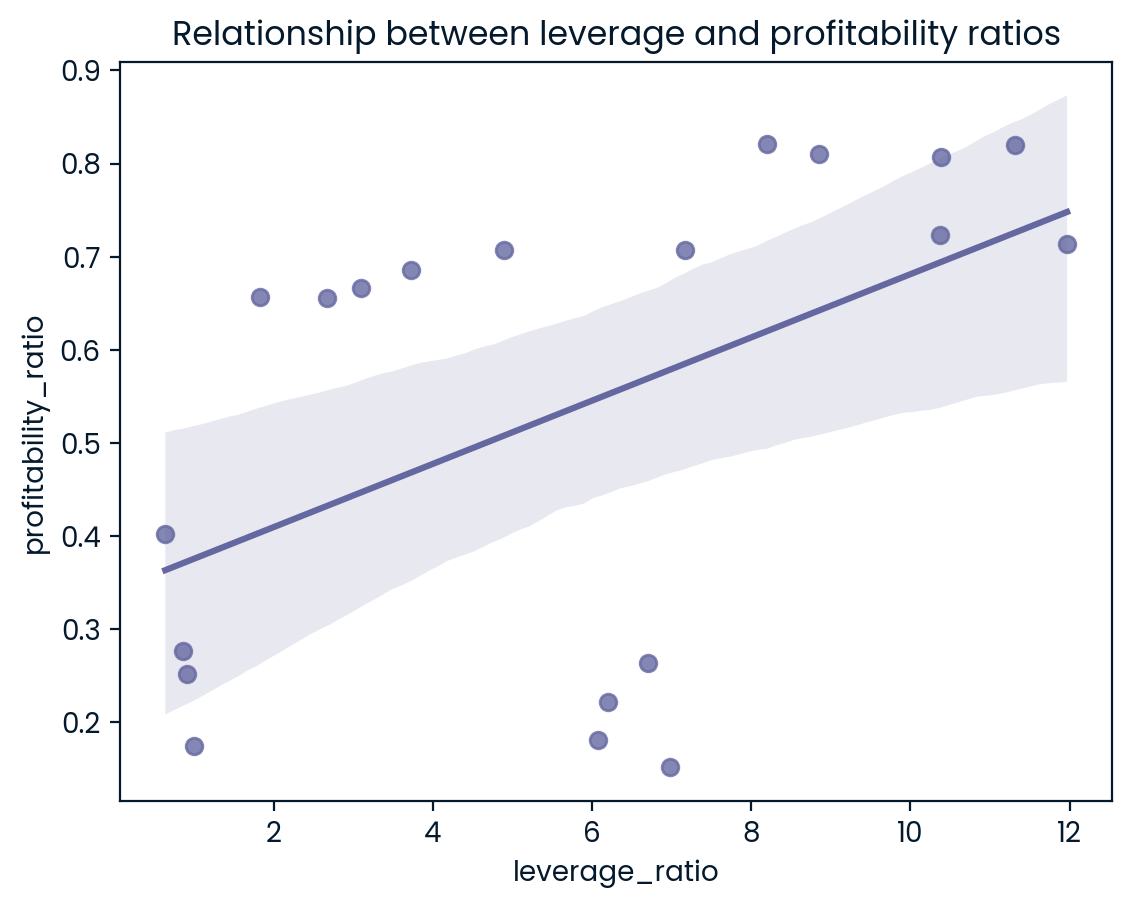

In [21]:
# Filter real estate companies
df_real_est = df_ratios.loc[df_ratios["comp_type"] == "real_est"]

# Plot leverage vs. profitability ratios
sns.regplot(data=df_real_est, x="leverage_ratio", y="profitability_ratio")
plt.title("Relationship between leverage and profitability ratios")
plt.show()

# Define relationship based on visual inspection
relationship = "positive"